# Appendix - The Growth of Functions



We use these libraries to build and visualize the objects we'll be using in this appendix:

| Package | Purpose |
|---|---|
| `io` | Basic library for handling input and output |
| `base64` | Manages special characters |
| `IPython` | Provides additional Python functionality |
| `numpy` | Basic numerical library |
| `matplotlib.pyplot` | Visualization library based on MATLAB |

The cell below checks whether each package is already installed and installs
it automatically if not. This is safe to re-run; it only installs what is
missing.

**Outside Jupyter**, install once from the terminal:
```bash
pip install io base64 IPython graphviz matplotlib
```

In [1]:
# Install required Python packages using pip
import sys
import importlib.util
import subprocess

def install_if_missing(package):
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"{package} has been installed")
    else:
        print(f"{package} is already installed")

required_packages = ['io', 'base64', 'IPython', 'numpy', 'matplotlib']
for package in required_packages:
    install_if_missing(package)

import numpy as np
import matplotlib.pyplot as plt

import io
import base64
from IPython.display import display, HTML

io is already installed
base64 is already installed
IPython is already installed
numpy is already installed
matplotlib is already installed


We'll be plotting the same two functions, just on different intervals, multiple times in this notebook. We'd like the graphs to be accessible, and so we'll create a helper function for plotting them.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper function for plotting accessible charts.
#
# Running outside Jupyter:
#   python plot_functions_accessible.py
# ─────────────────────────────────────────────────────────────────────────────

def plot_functions_accessible(
    func_list,
    x_min,
    x_max,
    fig_num,
    title,
    alt_text,
    num_points=100
):
    """
    Plots a list of mathematical functions over a specified interval [x_min, x_max],
    and displays the result accessibly with captioning.

    Parameters:
    - func_list (list): List of tuples, where each tuple is (function_callable, label_string).
                        Example: [(f, '$f(x)$'), (g, '$g(x)$')]
    - x_min (float): Start of the x-axis interval.
    - x_max (float): End of the x-axis interval.
    - fig_num (str): The figure number (e.g., "1", "3.2").
    - title (str): The descriptive title for the figure caption.
    - alt_text (str): The full accessible description for screen readers.
    - num_points (int): Resolution of the plot (default 100).
    """
    # 1. Generate the x-values based on the requested interval
    x = np.linspace(x_min, x_max, num_points)

    # 2. Create the plot
    plt.figure(figsize=(8, 6))

    # Calculate y-values dynamically for each function in the list
    for func, label in func_list:
        y = func(x)
        plt.plot(x, y, label=label)

    # Add formatting
    plt.xlabel('x')
    plt.ylabel('y')
    # Use LaTeX for the title inside the plot itself
    plt.title(f'Plot of $f(x)$ and $g(x)$ on [{x_min}, {x_max}]')
    plt.legend()
    plt.grid(True)

    # 3. Accessibility and Caption Setup
    figure_number_str = f"Figure {fig_num}"
    full_caption = f"<b>{figure_number_str}:</b> {title}"

    # 4. Save the plot to a memory buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)

    # 5. Close the plot (crucial)
    plt.close()

    # 6. Encode and Display
    img_data = base64.b64encode(buf.read()).decode('utf-8')
    mime_type = "image/png"

    html_output = f"""
    <figure style="text-align: center; margin: 1em 0;">
        <img src="data:{mime_type};base64,{img_data}" alt="{alt_text}"
             style="max-width: 100%; height: auto; display: block; margin: 0 auto;" />
        <figcaption style="margin-top: 0.5em; font-size: 0.9em; color: #333;">
            {full_caption}
        </figcaption>
    </figure>
    """
    display(HTML(html_output))

Suppose we take two functions:

<center>

  $f(x) = 3x^{2} + 14x + 9$
    
  and
    
  $g(x) = x^{3}$

</center>

In [3]:
def f(x):
    """Represents f(x) = 3x^2 + 14x + 9"""
    return 3 * x**2 + 14 * x + 9

def g(x):
    """Represents g(x) = x^3"""
    return x**3

If we take a look at these functions on the interval $[0,1]$ they look like this:


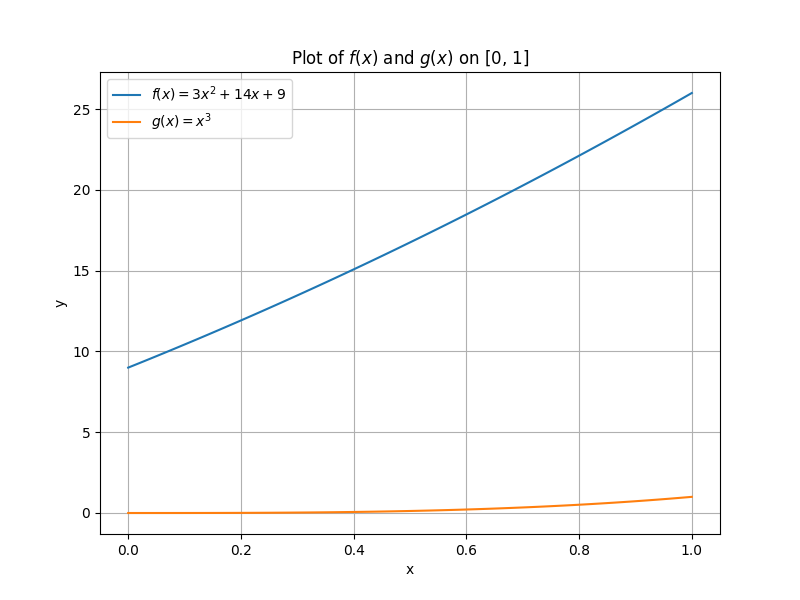

In [4]:
plot_functions_accessible(
    func_list=[
        (f, '$f(x) = 3x^2 + 14x + 9$'),
        (g, '$g(x) = x^3$')
    ],
    x_min=0,
    x_max=1,
    fig_num="1",
    title="Comparison of f(x) and g(x) on the interval [0, 1]",
    alt_text="A line graph comparing two functions, f(x) and g(x), from x=0 to x=1. f(x) starts at y=9 and rises steeply to y=26. g(x) starts at 0 and rises very slowly to 1. The graph clearly shows f(x) is significantly larger than g(x) over this interval."
)

On this interval $f(x)$ is *way* above $g(x)$. But, if we zoom out a bit and take a look at the interval $[0,5]$, it look like:


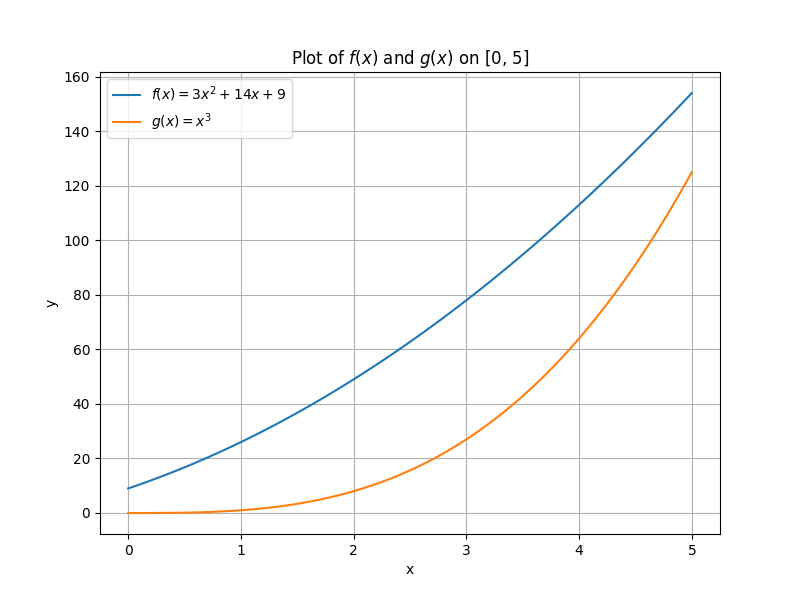

In [5]:
plot_functions_accessible(
    func_list=[
        (f, '$f(x) = 3x^2 + 14x + 9$'),
        (g, '$g(x) = x^3$')
    ],
    x_min=0,
    x_max=5,
    fig_num="2",
    title="Comparison of f(x) and g(x) on the interval [0, 5]",
    alt_text="A line graph comparing two functions, f(x) and g(x), from x=0 to x=5. f(x) starts at y=9 and rises steadily in a concave-upward curve, ending at y=154. g(x) starts at 0 and rises in a concave-upward curve, ending at y=125. The function f(x) is initially much larger than g(x), but g(x) is catching up rapidly."
)

It appears $g(x)$ is catching up. Let's zoom out a bit more and look at the interval $[0,10]$:


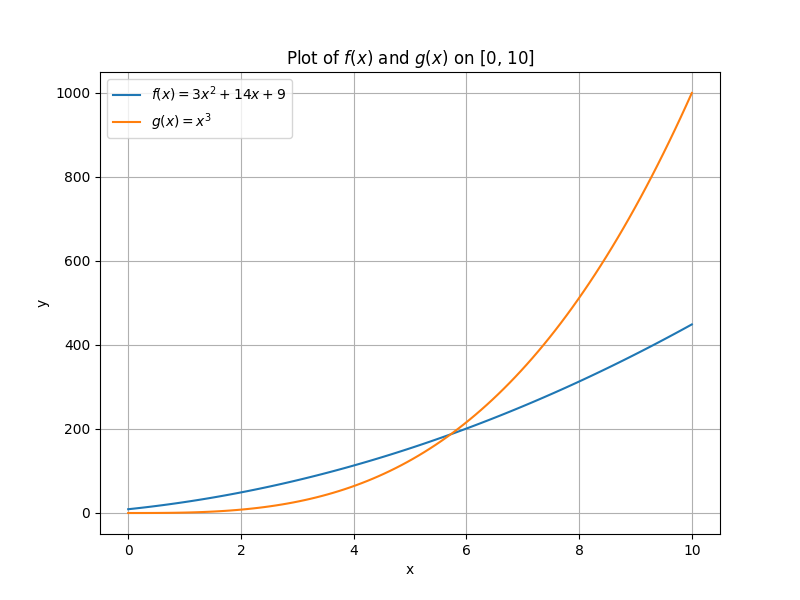

In [6]:
plot_functions_accessible(
    func_list=[
        (f, '$f(x) = 3x^2 + 14x + 9$'),
        (g, '$g(x) = x^3$')
    ],
    x_min=0,
    x_max=10,
    fig_num="3",
    title="Comparison of f(x) and g(x) on the interval [0, 10]",
    alt_text="A line graph comparing two functions, f(x) and g(x), from x=0 to x=10. f(x) starts at y=9 and rises steadily, ending at y=449. g(x) starts at 0 and rises slowly at first, but steeply accelerates to y=1000. The functions cross near x=5.5. f(x) is initially greater than g(x) until the crossover, after which g(x) becomes significantly larger than f(x)."
)

Whoa! Not only has $g(x)$ caught up, it's jumped quite a ways ahead. It's over twice the value of $f(x)$ at $x = 10$. Now what happens if we go really big? Say, take a look at the interval $[0,100]$?


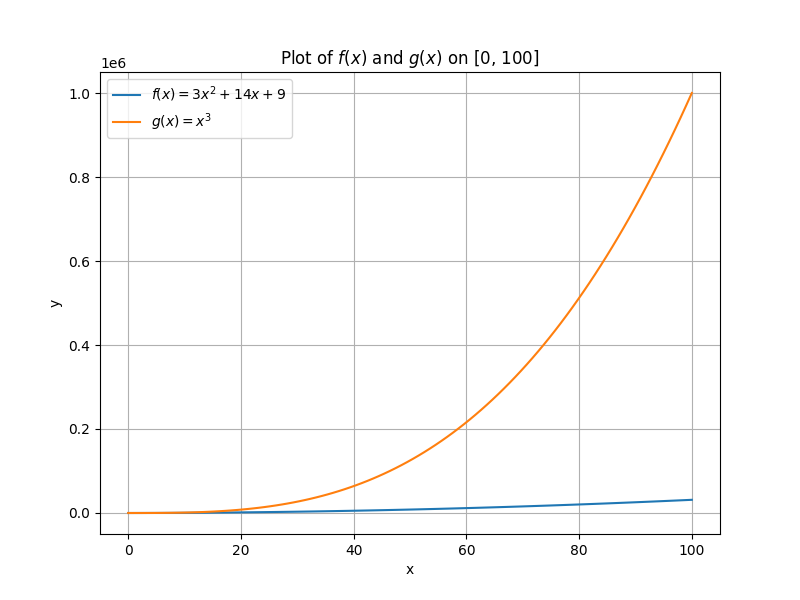

In [7]:
plot_functions_accessible(
    func_list=[
        (f, '$f(x) = 3x^2 + 14x + 9$'),
        (g, '$g(x) = x^3$')
    ],
    x_min=0,
    x_max=100,
    fig_num="4",
    title="Comparison of f(x) and g(x) on the interval [0, 100]",
    alt_text="A line graph comparing the functions f(x) and g(x) across the interval x=0 to x=100. f(x), a quadratic, starts at y=9 and rises consistently to an endpoint value of 31,409. g(x), a cubic function, starts at 0, remains below f(x) until the crossover point near x=5.6, and then accelerates rapidly, ending at a massive value of 1,000,000. After the crossover, g(x) dominates the plot, making f(x) appear flat for most of the graph."
)

Well, here the function $g(x)$ has left $f(x)$ completely behind. When we're talking about the growth of functions, this is what we're talking about. We're looking at how functions behave as their input gets large. In this case, $g(x)$ grows significantly faster than $f(x)$. To express this idea, that $f(x)$ is bounding or dominating $g(x)$ from above, we use something called "big-O" notation, and write this as:

<center>

  The function $g(x)$ is $O(f(x))$.

</center>

These ideas are particularly important when applied to the study of algorithms and their complexity.

## 1. The Formal Definition

We formally define "big-O" as:

---

**Definition** - Let $f$ and $g$ be functions from the set of integers or the set of real numbers to the set of real numbers. We say that $f(x)$ is $O(g(x))$ if there are constants $C$ and $k$ such that


$$|f(x)| \leq C|g(x)|$$

whenever $x > k$.

---

We will essentially always be dealing with non-negative functions, so from now on we'll drop the absolute value signs. Two things to note:

  1. Positive constant multiples don't matter. So, we don't distinguish between $2x^{2}$ and $12x^{2}$ in terms of the second growing faster than the first. They're both in the same class.

  2. The only thing that matters is the behavior for large inputs - specifically their behavior beyond some number $k$.

---

**Example** - The function $f(x) = 10$ is $O(x)$ with $C = 10$ and $k = 1$. The function $f(x) = 3x+7$ is $O(x)$ with $C = 4$ and $k = 7$.

---

The constants $C$ and $k$ are called *witnesses* to the relationship. Note they are definitely not unique, and in fact if $C$ and $k$ are witnesses, then any larger values for $C$ and $k$ would work as well.

## 2. Properties

The growth of the sum of two functions is governed by the faster growing function, so that if $f_{1}(x)$ is $O(g_{1}(x))$ and $f_{2}(x)$ is $O(g_{2}(x))$ then $f_{1}(x) + f_{2}(x)$ is $O(max(g_{1}(x),g_{2}(x)))$. From this we can see that if $f(x)$ is a polynomial, so $f(x) = a_{n}x^{n} + a_{n-1}x^{n-1} + \cdots + a_{1}x + a_{0}$ with $a_{n} \neq 0$, then $f(x)$ is $O(x^{n})$.

The growth of the product of two functions is the product of their growths. So, if $f_{1}(x)$ is $O(g_{1}(x))$ and $f_{2}(x)$ is $O(g_{2}(x))$ then $(f_{1}f_{2})(x)$ is $O(g_{1}(x)g_{2}(x))$.

In big-O notation, the function in the $O$ dominates the other function in that eventually, with the right witnesses, it will be larger. We can also go the other way and talk about  functions that eventually will always be smaller.

---

**Definition** Let $f$ and $g$ be functions from the set of integers or the set of real numbers to the set of real numbers. We say that $f(x)$ is $\Omega(g(x))$ if there are constants $C$ and $k$ with $C$ positive such that

$$f(x) \geq Cg(x)$$

whenever $x > k$.

---

This is called, not surprisingly, big-omega notation.

---

**Definition** - Let $f$ and $g$ be functions as above. If $f$ is both $O(g)$ and $\Omega(g)$ then it is $\Theta(g)$.

---

This is called, you guessed it, big-theta notation.

## 3. Complexity Classes

These concepts are important in the analysis of algorithms, where we're interested in determining the complexity class of a given algorithm relative to the size of its inputs. Certain orders of complexity are commonly encountered in algorithmic analysis, and are given their own terminology.

* $\Theta(1)$ Constant complexity
* $\Theta(\log{n})$ Logarithmic complexity
* $\Theta(n)$ Linear complexity
* $\Theta(n \log{n})$ Linearithmic complexity
* $\Theta(n^{b})$ Polynomial complexity
* $\Theta(b^{n})$ (where $b > 1$) Exponential complexity
* $\Theta(n!)$ Factorial complexity

## 4. References and Further Reading

* Discrete Mathematics and Its Applications (Eighth Edition) by Kenneth H. Rosen

  *Section 3.2 - The Growth of Functions*

* The Art of Computer Programming by Donald Knuth